In [7]:
import pandas as pd

df = pd.read_csv("Exam_Score_Prediction.csv")
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [3]:
df.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [4]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


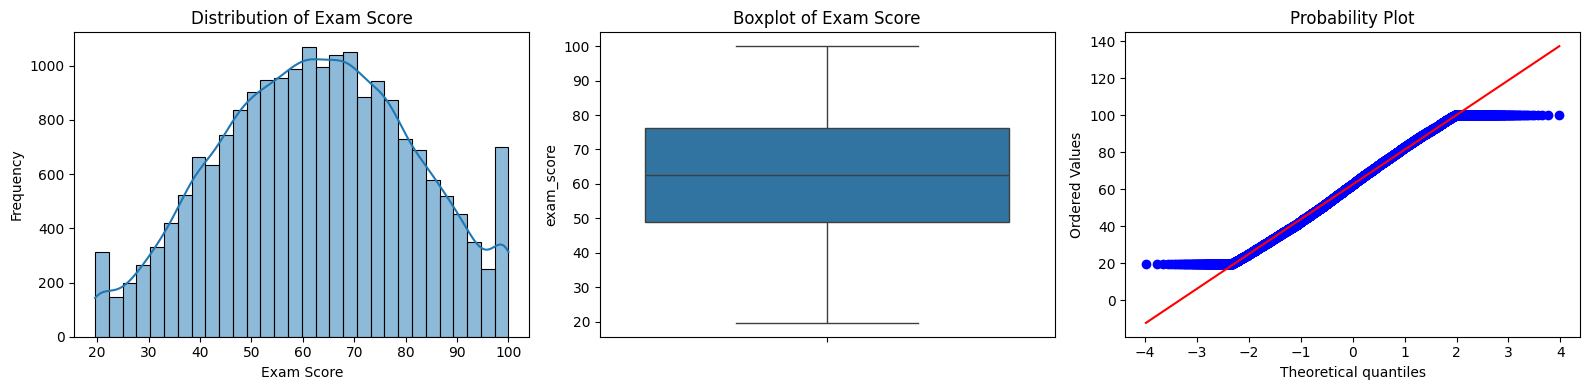

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
sns.histplot(df["exam_score"], bins=30, kde=True)
plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.boxplot(y=df["exam_score"])
plt.title("Boxplot of Exam Score")
plt.ylabel("exam_score")

plt.subplot(1, 3, 3)
stats.probplot(df["exam_score"], dist="norm", plot=plt)
plt.title("Probability Plot")

plt.tight_layout()
plt.show()

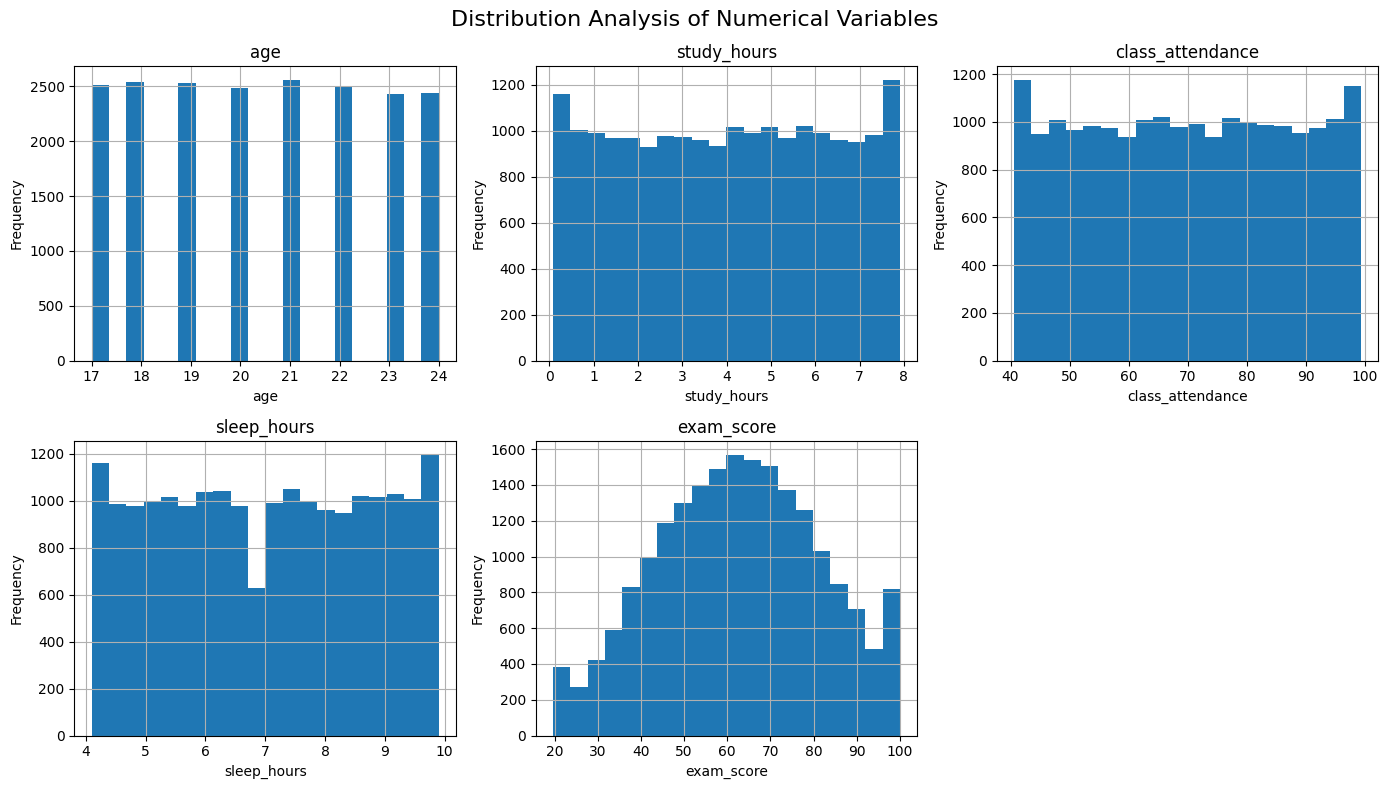

In [6]:
import matplotlib.pyplot as plt

numeric_cols = ["age", "study_hours", "class_attendance", "sleep_hours", "exam_score"]

plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)

plt.suptitle("Distribution Analysis of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

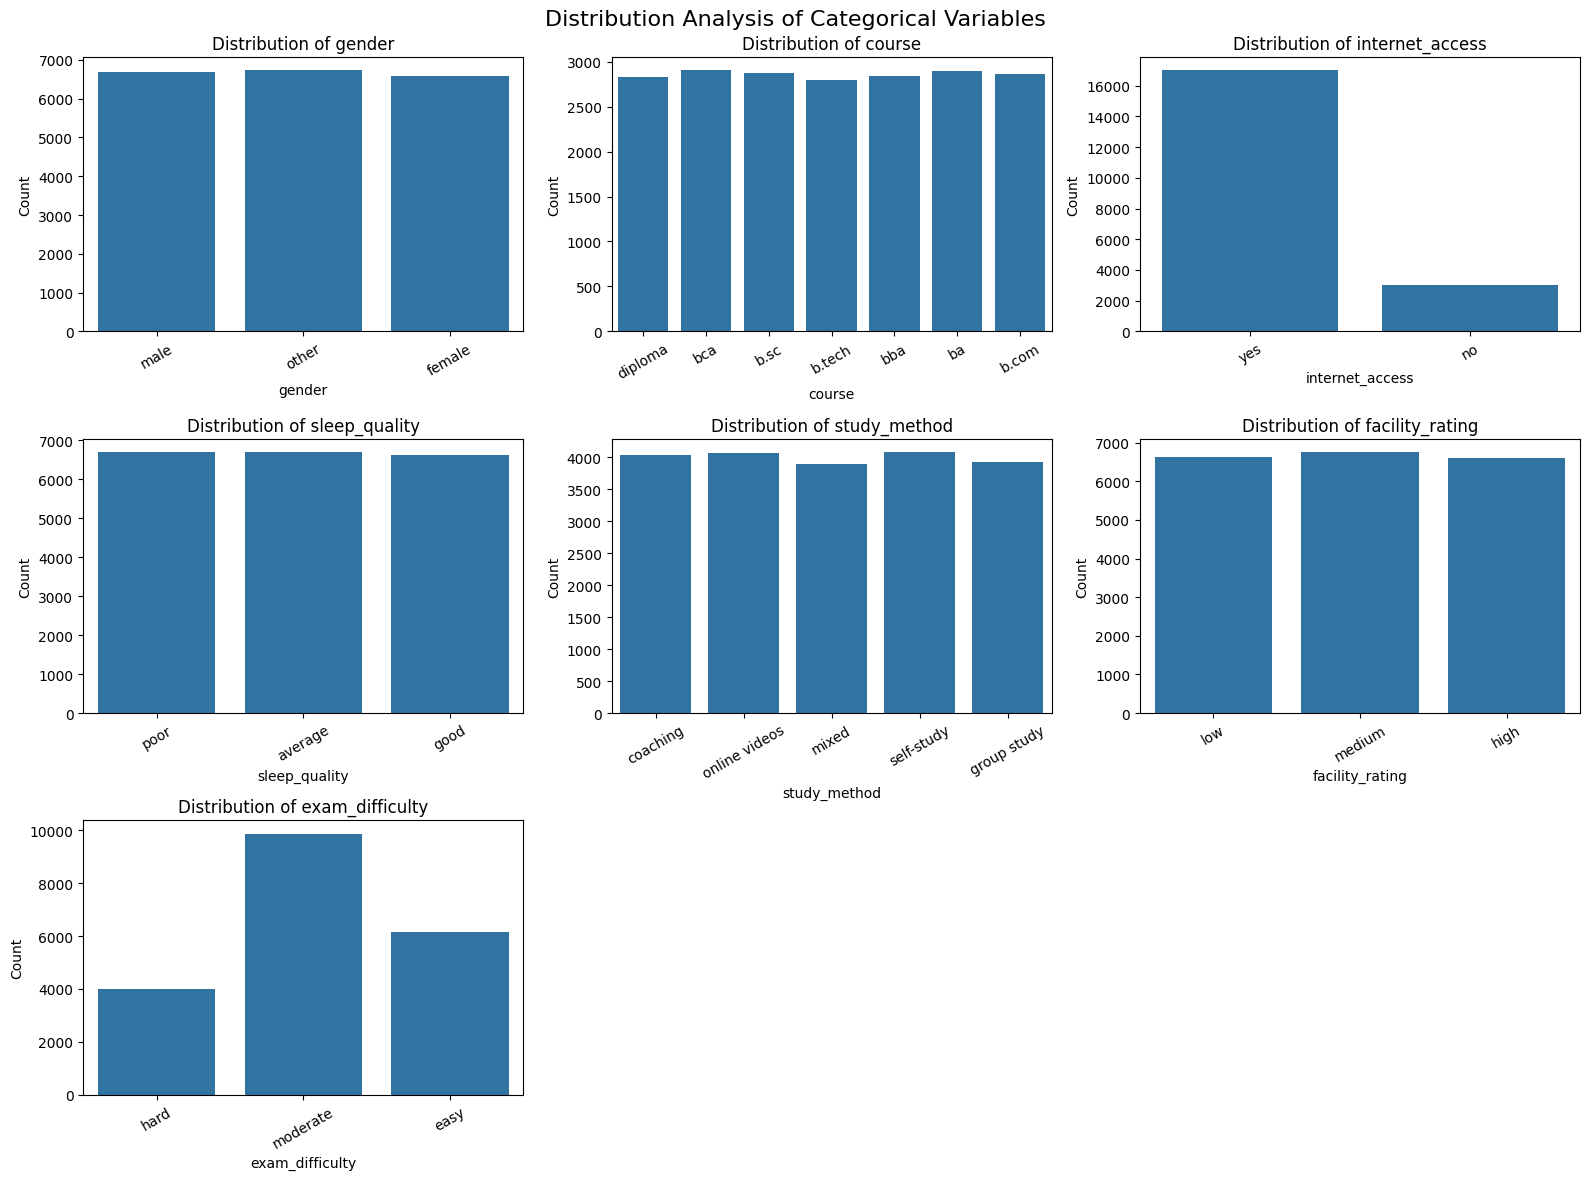

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    "gender",
    "course",
    "internet_access",
    "sleep_quality",
    "study_method",
    "facility_rating",
    "exam_difficulty"
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)

plt.suptitle("Distribution Analysis of Categorical Variables", fontsize=16)
plt.tight_layout()
plt.show()

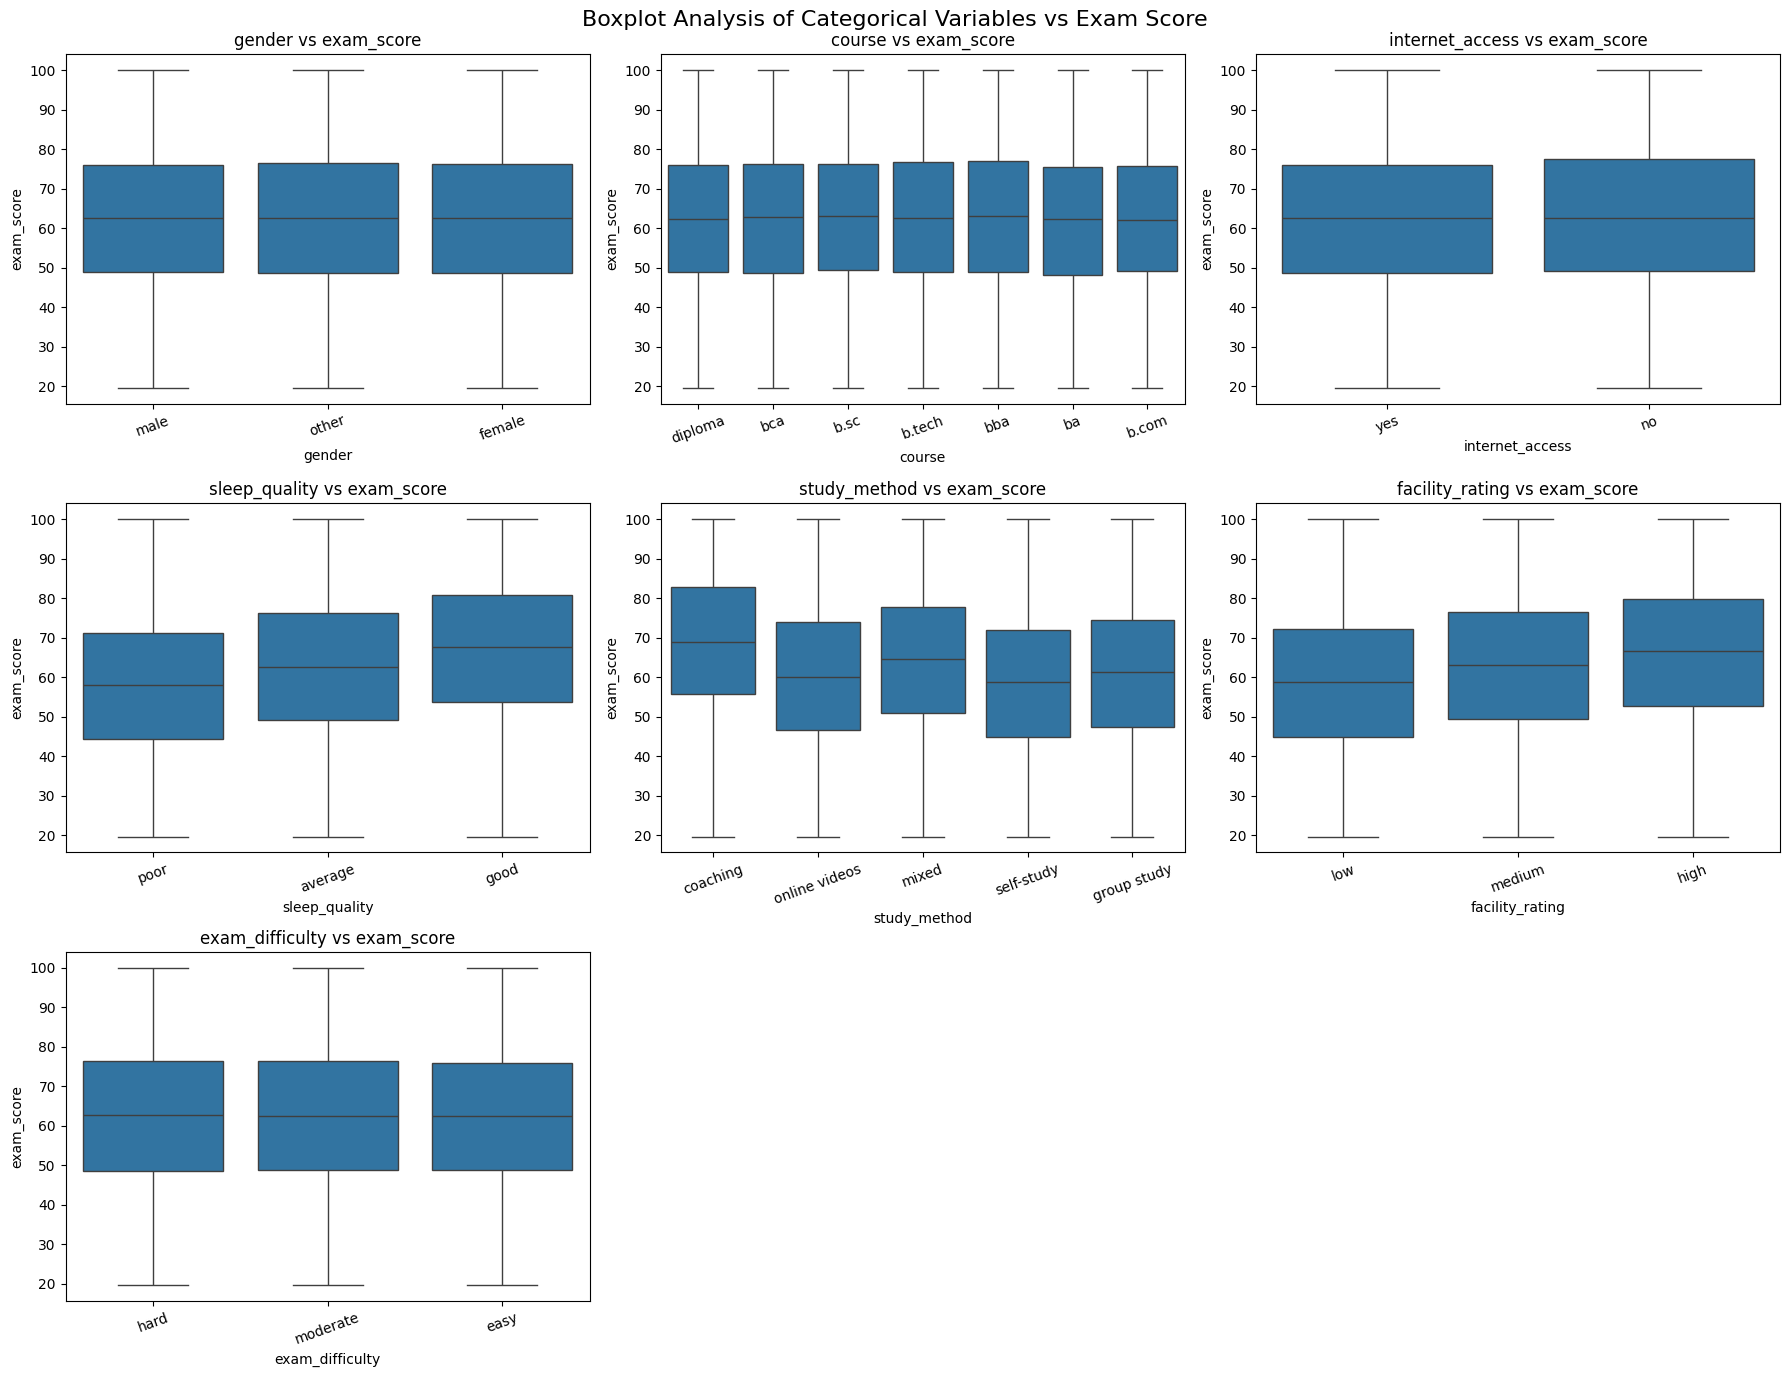

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    "gender",
    "course",
    "internet_access",
    "sleep_quality",
    "study_method",
    "facility_rating",
    "exam_difficulty"
]

plt.figure(figsize=(18, 14))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], y=df["exam_score"])
    plt.title(f"{col} vs exam_score")
    plt.xticks(rotation=20)

plt.suptitle("Boxplot Analysis of Categorical Variables vs Exam Score", fontsize=16)
plt.tight_layout()
plt.show()

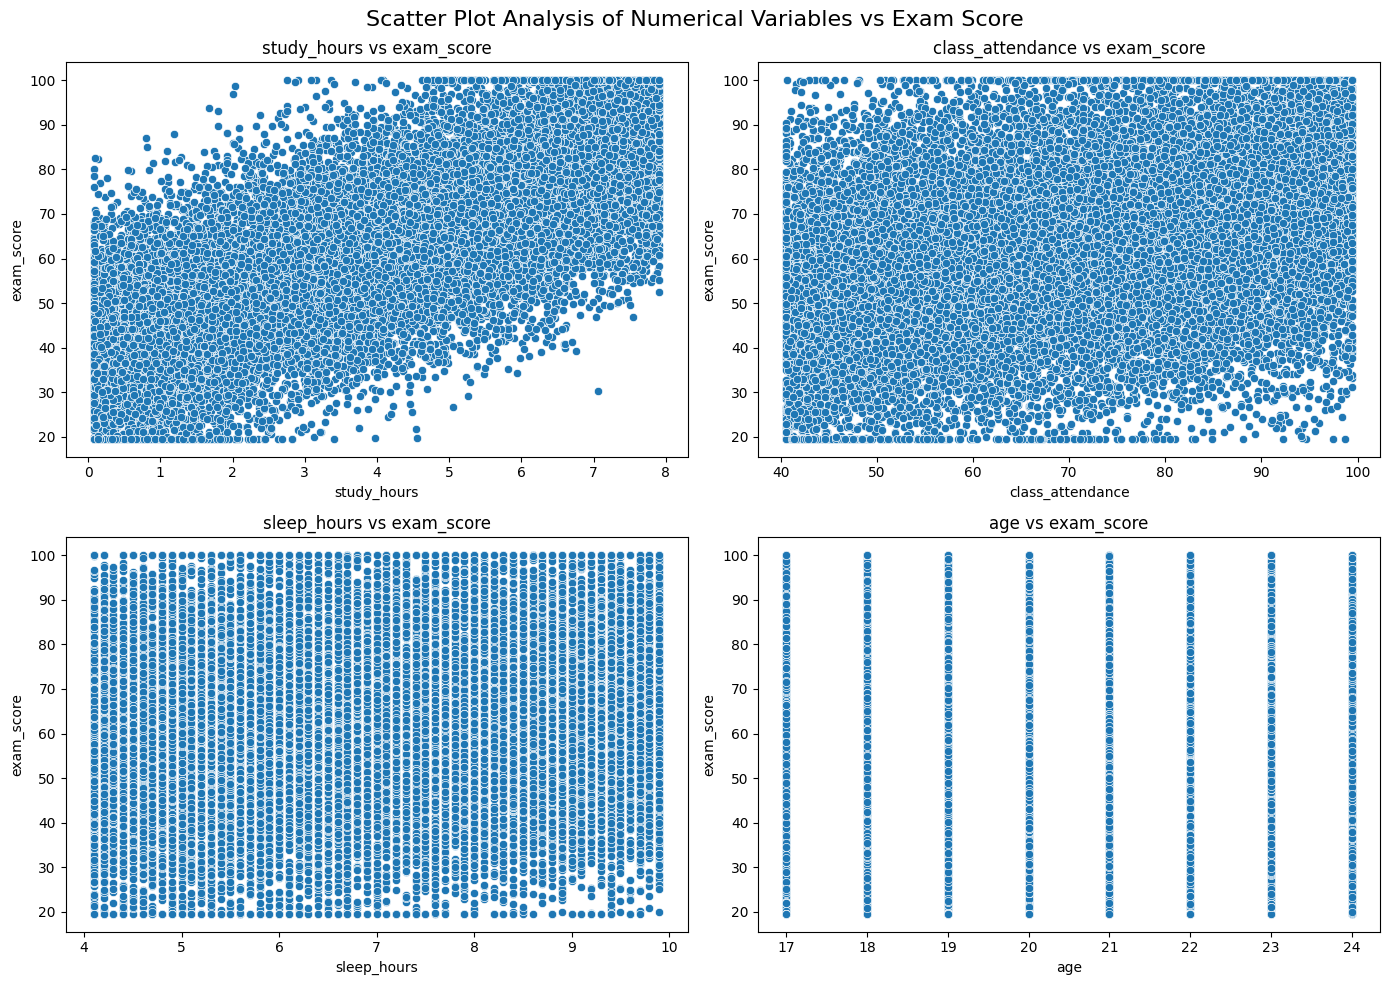

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = ["study_hours", "class_attendance", "sleep_hours", "age"]

plt.figure(figsize=(14, 10))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(data=df, x=col, y="exam_score")
    plt.title(f"{col} vs exam_score")
    plt.xlabel(col)
    plt.ylabel("exam_score")

plt.suptitle("Scatter Plot Analysis of Numerical Variables vs Exam Score", fontsize=16)
plt.tight_layout()
plt.show()

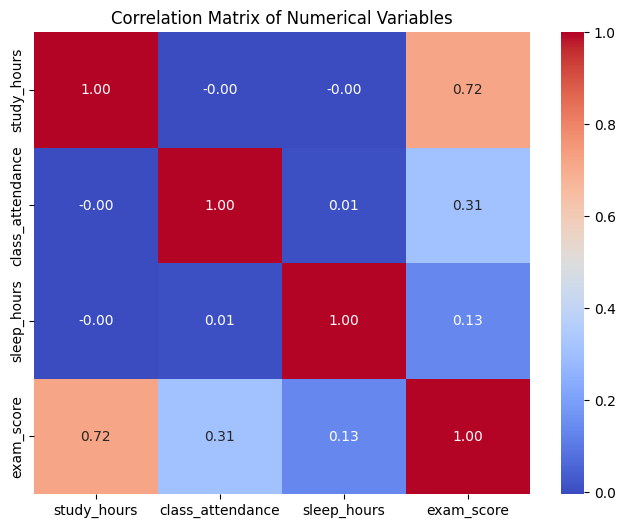

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[["study_hours", "class_attendance", "sleep_hours", "exam_score"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [8]:
X = df.drop(["student_id", "exam_score"], axis=1)
y = df["exam_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 11)
y shape: (20000,)


In [11]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['age', 'study_hours', 'class_attendance', 'sleep_hours'], dtype='object')

Categorical Features:
Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16000, 11)
X_test shape: (4000, 11)
y_train shape: (16000,)
y_test shape: (4000,)


In [14]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (16000, 30)
X_test_processed shape: (4000, 30)


In [16]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_train_processed_df.head()

,num__age,num__study_hours,num__class_attendance,num__sleep_hours,cat__gender_female,cat__gender_male,cat__gender_other,cat__course_b.com,cat__course_b.sc,cat__course_b.tech,...,cat__study_method_group study,cat__study_method_mixed,cat__study_method_online videos,cat__study_method_self-study,cat__facility_rating_high,cat__facility_rating_low,cat__facility_rating_medium,cat__exam_difficulty_easy,cat__exam_difficulty_hard,cat__exam_difficulty_moderate
0,0.237226,1.239349,-0.756186,1.156364,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.638047,1.256681,-0.889533,1.214028,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-0.200410,0.624091,1.696234,0.349059,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-0.200410,0.312128,-1.306966,0.003071,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-1.513320,-0.086490,0.490316,0.464388,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_processed, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred = model.predict(X_test_processed)

print(y_pred[:10])

[ 36.79712092  79.95720905  54.43249825 102.14749404  80.63235549
  39.30385838  55.40588587  75.82269437  67.42144057  29.05009255]


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
y_pred = model.predict(X_test_processed)
y_pred = np.clip(y_pred, 0, 100)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 7.8494403906787795
MSE: 95.3876425750323
RMSE: 9.766659745021954
R² Score: 0.7333283817792484


In [25]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_processed, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [26]:
ridge_y_pred = ridge_model.predict(X_test_processed)

ridge_y_pred = np.clip(ridge_y_pred, 0, 100)

print(ridge_y_pred[:10])

[ 36.79908618  79.9536449   54.43363828 100.          80.63182605
  39.30550172  55.40693733  75.82090152  67.42042399  29.05350401]


In [27]:
ridge_mae = mean_absolute_error(y_test, ridge_y_pred)
ridge_mse = mean_squared_error(y_test, ridge_y_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_y_pred)

print("Ridge Regression MAE:", ridge_mae)
print("Ridge Regression MSE:", ridge_mse)
print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R² Score:", ridge_r2)

Ridge Regression MAE: 7.849505639692532
Ridge Regression MSE: 95.38803857646711
Ridge Regression RMSE: 9.766680018126278
Ridge Regression R² Score: 0.733327274693041


In [28]:
ridge_comparison_table = pd.DataFrame({
    "Actual Exam Score": y_test.iloc[:10].values,
    "Ridge Regression Prediction": ridge_y_pred[:10]
})

ridge_comparison_table

,Actual Exam Score,Ridge Regression Prediction
0,31.1,36.799086
1,81.6,79.953645
2,68.0,54.433638
3,100.0,100.000000
4,84.8,80.631826
5,52.8,39.305502
6,53.1,55.406937
7,81.0,75.820902
8,72.6,67.420424
9,25.4,29.053504


In [29]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01, max_iter=10000)

lasso_model.fit(X_train_processed, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [30]:
lasso_y_pred = lasso_model.predict(X_test_processed)

lasso_y_pred = np.clip(lasso_y_pred, 0, 100)

print(lasso_y_pred[:10])

[ 36.86106489  80.03863729  54.46138644 100.          80.60426041
  39.41257291  55.41246834  75.70646374  67.32855848  29.09592518]


In [31]:
lasso_mae = mean_absolute_error(y_test, lasso_y_pred)
lasso_mse = mean_squared_error(y_test, lasso_y_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_y_pred)

print("Lasso Regression MAE:", lasso_mae)
print("Lasso Regression MSE:", lasso_mse)
print("Lasso Regression RMSE:", lasso_rmse)
print("Lasso Regression R² Score:", lasso_r2)

Lasso Regression MAE: 7.850985517162527
Lasso Regression MSE: 95.370135531809
Lasso Regression RMSE: 9.765763438247365
Lasso Regression R² Score: 0.7333773255566663


In [32]:
lasso_comparison_table = pd.DataFrame({
    "Actual Exam Score": y_test.iloc[:10].values,
    "Lasso Regression Prediction": lasso_y_pred[:10]
})

lasso_comparison_table

,Actual Exam Score,Lasso Regression Prediction
0,31.1,36.861065
1,81.6,80.038637
2,68.0,54.461386
3,100.0,100.000000
4,84.8,80.604260
5,52.8,39.412573
6,53.1,55.412468
7,81.0,75.706464
8,72.6,67.328558
9,25.4,29.095925


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
rf_y_pred = rf_model.predict(X_test_processed)

rf_y_pred = np.clip(rf_y_pred, 0, 100)

print(rf_y_pred[:10])

[36.69094 73.89    57.754   95.796   85.366   37.46199 51.1     70.209
 62.926   28.29178]


In [35]:
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_y_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 8.313119805
Random Forest MSE: 106.43980123531807
Random Forest RMSE: 10.316966668324469
Random Forest R² Score: 0.7024302805660587


In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [37]:
gb_y_pred = gb_model.predict(X_test_processed)

print(gb_y_pred[:10])

[36.0248518  78.36566814 54.55835319 98.40479719 80.18691827 39.21745725
 56.10340024 75.40253274 66.05055984 32.16820262]


In [38]:
gb_y_pred = np.clip(gb_y_pred, 0, 100)

gb_mae = mean_absolute_error(y_test, gb_y_pred)
gb_mse = mean_squared_error(y_test, gb_y_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_y_pred)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting MSE:", gb_mse)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R² Score:", gb_r2)

Gradient Boosting MAE: 7.939372333407291
Gradient Boosting MSE: 97.02111521077076
Gradient Boosting RMSE: 9.84992970587967
Gradient Boosting R² Score: 0.728761744221883


In [39]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [40]:
xgb_y_pred = xgb_model.predict(X_test_processed)

xgb_y_pred = np.clip(xgb_y_pred, 0, 100)

print(xgb_y_pred[:10])

[34.522144 77.71394  54.66696  98.28535  81.612076 39.28416  55.091404
 74.6161   65.758125 31.563036]


In [41]:
xgb_mae = mean_absolute_error(y_test, xgb_y_pred)
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost MSE:", xgb_mse)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R² Score:", xgb_r2)

XGBoost MAE: 7.953750530044555
XGBoost MSE: 97.42683101431584
XGBoost RMSE: 9.870503078076407
XGBoost R² Score: 0.7276274999220095


In [42]:
xgb_comparison_table = pd.DataFrame({
    "Actual Exam Score": y_test.iloc[:10].values,
    "XGBoost Prediction": xgb_y_pred[:10]
})

xgb_comparison_table

,Actual Exam Score,XGBoost Prediction
0,31.1,34.522144
1,81.6,77.713943
2,68.0,54.666962
3,100.0,98.285347
4,84.8,81.612076
5,52.8,39.284161
6,53.1,55.091404
7,81.0,74.616096
8,72.6,65.758125
9,25.4,31.563036


In [44]:
model_comparison = pd.DataFrame([
    ["Linear Regression", mae, mse, rmse, r2],
    ["Ridge Regression", ridge_mae, ridge_mse, ridge_rmse, ridge_r2],
    ["Lasso Regression", lasso_mae, lasso_mse, lasso_rmse, lasso_r2],
    ["Random Forest", rf_mae, rf_mse, rf_rmse, rf_r2],
    ["Gradient Boosting", gb_mae, gb_mse, gb_rmse, gb_r2],
    ["XGBoost", xgb_mae, xgb_mse, xgb_rmse, xgb_r2]
], columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"])

model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,7.849440,95.387643,9.766660,0.733328
1,Ridge Regression,7.849506,95.388039,9.766680,0.733327
2,Lasso Regression,7.850986,95.370136,9.765763,0.733377
3,Random Forest,8.313120,106.439801,10.316967,0.702430
4,Gradient Boosting,7.939372,97.021115,9.849930,0.728762
5,XGBoost,7.953751,97.426831,9.870503,0.727627


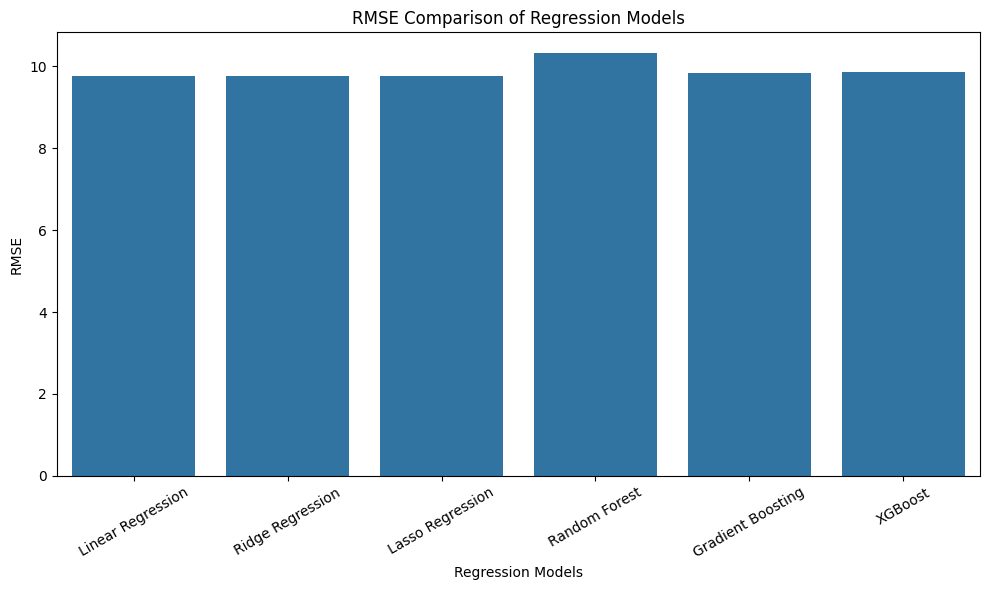

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison of Regression Models")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [46]:
comparison_table = pd.DataFrame({
    "Actual Exam Score": y_test.iloc[:10].values,
    
    "Linear Regression": y_pred[:10],
    
    "Ridge Regression": ridge_y_pred[:10],
    
    "Lasso Regression": lasso_y_pred[:10],
    
    "Random Forest": rf_y_pred[:10],
    
    "Gradient Boosting": gb_y_pred[:10],
    
    "XGBoost": xgb_y_pred[:10]
})

comparison_table

,Actual Exam Score,Linear Regression,Ridge Regression,Lasso Regression,Random Forest,Gradient Boosting,XGBoost
0,31.1,36.797121,36.799086,36.861065,36.69094,36.024852,34.522144
1,81.6,79.957209,79.953645,80.038637,73.89000,78.365668,77.713943
2,68.0,54.432498,54.433638,54.461386,57.75400,54.558353,54.666962
3,100.0,100.000000,100.000000,100.000000,95.79600,98.404797,98.285347
4,84.8,80.632355,80.631826,80.604260,85.36600,80.186918,81.612076
5,52.8,39.303858,39.305502,39.412573,37.46199,39.217457,39.284161
6,53.1,55.405886,55.406937,55.412468,51.10000,56.103400,55.091404
7,81.0,75.822694,75.820902,75.706464,70.20900,75.402533,74.616096
8,72.6,67.421441,67.420424,67.328558,62.92600,66.050560,65.758125
9,25.4,29.050093,29.053504,29.095925,28.29178,32.168203,31.563036


In [50]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,num__study_hours,0.566875
2,num__class_attendance,0.152329
3,num__sleep_hours,0.062574
19,cat__study_method_coaching,0.026670
0,num__age,0.024497
18,cat__sleep_quality_poor,0.020637
17,cat__sleep_quality_good,0.016744
25,cat__facility_rating_low,0.015617
24,cat__facility_rating_high,0.014299
21,cat__study_method_mixed,0.006446


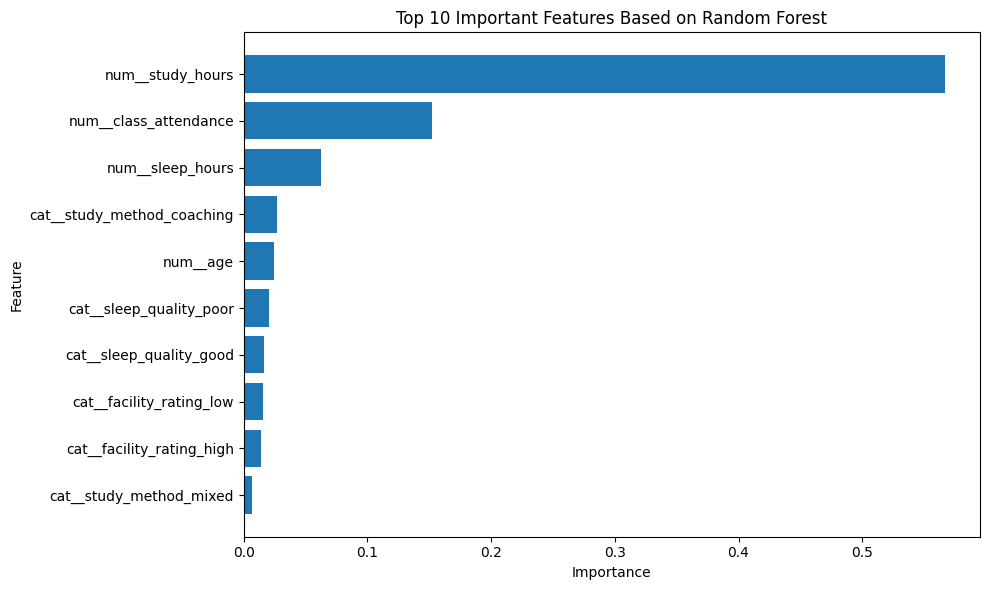

In [51]:
import matplotlib.pyplot as plt

top_10_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features["Feature"],
    top_10_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 10 Important Features Based on Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()